# 03 — Inter-Judge Agreement

This notebook measures how well the three LLM judges agree with each other.

## Metrics used

- **Cohen's kappa** — pairwise agreement between two judges, corrected for chance. Values: <0 no agreement, 0–0.2 slight, 0.2–0.4 fair, 0.4–0.6 moderate, 0.6–0.8 substantial, >0.8 near-perfect.
- **Fleiss' kappa** — generalisation of Cohen's kappa to k>2 judges simultaneously.
- **Spearman correlation** — rank-order correlation on continuous scores; immune to monotone rescaling but not to systematic bias.

## Provocative claim

> "When bucketed into low / mid / high categories, the three LLM judges agree on only **~61%** of instances — barely above the majority-class baseline for a balanced three-class problem."

The cells below verify (or refute) this claim with the actual data.


In [1]:
# Setup: path, imports, and data-loading helper
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.agreement.kappa import cohen_kappa, fleiss_kappa, bucketize
from src.agreement.correlation import spearman
from src.visualisation import kappa_heatmap

METRICS = ["context_relevance", "groundedness", "answer_relevance"]


def load_all_scores(root: Path) -> dict:
    """Discover scored models from data/eval/scores_*.json and load them.

    Only loads files that are non-empty and contain at least one non-NaN score.
    Model name is read from the records themselves (the 'model' field), so no
    filename-to-model mapping is needed.
    """
    result = {}
    eval_dir = root / "data" / "eval"
    for path in sorted(eval_dir.glob("scores_*.json")):
        records = json.loads(path.read_text())
        if not records:
            continue
        df = pd.DataFrame(records)
        if df["score"].isna().all():
            continue
        model = df["model"].iloc[0]
        model_scores = {}
        for metric in METRICS:
            sub = df[df["metric"] == metric].sort_values("id")
            model_scores[metric] = sub["score"].to_numpy()
        result[model] = model_scores
    return result


print("Setup complete. ROOT =", ROOT)

FIGURES_DIR = ROOT / "outputs" / "figures"
RESULTS_DIR = ROOT / "outputs" / "results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

Setup complete. ROOT = /workspaces/llm_judge_benchmark


In [2]:
# Load scores — MODELS is derived from whatever score files are present in data/eval/
scores = load_all_scores(ROOT)

MODELS = [k for k in scores]
print(f"Judge models found: {MODELS}")
print(f"Total annotators: {len(MODELS)}")
print()
for annotator, metric_dict in scores.items():
    for metric, arr in metric_dict.items():
        print(f"  {annotator:20s}  {metric:25s}  n={len(arr)}")

Judge models found: ['gemma3:4b', 'llama3.1:8b', 'qwen2.5:7b']
Total annotators: 3

  gemma3:4b             context_relevance          n=50
  gemma3:4b             groundedness               n=50
  gemma3:4b             answer_relevance           n=50
  llama3.1:8b           context_relevance          n=50
  llama3.1:8b           groundedness               n=50
  llama3.1:8b           answer_relevance           n=50
  qwen2.5:7b            context_relevance          n=50
  qwen2.5:7b            groundedness               n=50
  qwen2.5:7b            answer_relevance           n=50


In [3]:
# Pairwise Cohen's kappa matrices (3×3) for each metric
available = MODELS

kappa_matrices = {}
for metric in METRICS:
    rows = []
    for a1 in available:
        row = []
        for a2 in available:
            if a1 == a2:
                row.append(1.0)
            else:
                s1 = scores[a1][metric]
                s2 = scores[a2][metric]
                min_len = min(len(s1), len(s2))
                row.append(cohen_kappa(s1[:min_len], s2[:min_len]))
        rows.append(row)
    df_kappa = pd.DataFrame(rows, index=available, columns=available)
    kappa_matrices[metric] = df_kappa
    print(f"\n=== Cohen's Kappa: {metric} ===")
    print(df_kappa.round(3).to_string())

# Persist kappa matrices
kappa_export = {metric: df.to_dict() for metric, df in kappa_matrices.items()}
kappa_path = RESULTS_DIR / "03_cohen_kappa_matrices.json"
kappa_path.write_text(json.dumps(kappa_export, indent=2))
print(f"Saved kappa matrices to {kappa_path}")


=== Cohen's Kappa: context_relevance ===
             gemma3:4b  llama3.1:8b  qwen2.5:7b
gemma3:4b        1.000       -0.099       0.289
llama3.1:8b     -0.099        1.000       0.077
qwen2.5:7b       0.289        0.077       1.000

=== Cohen's Kappa: groundedness ===
             gemma3:4b  llama3.1:8b  qwen2.5:7b
gemma3:4b        1.000        0.546       0.723
llama3.1:8b      0.546        1.000       0.631
qwen2.5:7b       0.723        0.631       1.000

=== Cohen's Kappa: answer_relevance ===
             gemma3:4b  llama3.1:8b  qwen2.5:7b
gemma3:4b        1.000        0.233       0.828
llama3.1:8b      0.233        1.000       0.146
qwen2.5:7b       0.828        0.146       1.000
Saved kappa matrices to /workspaces/llm_judge_benchmark/outputs/results/03_cohen_kappa_matrices.json


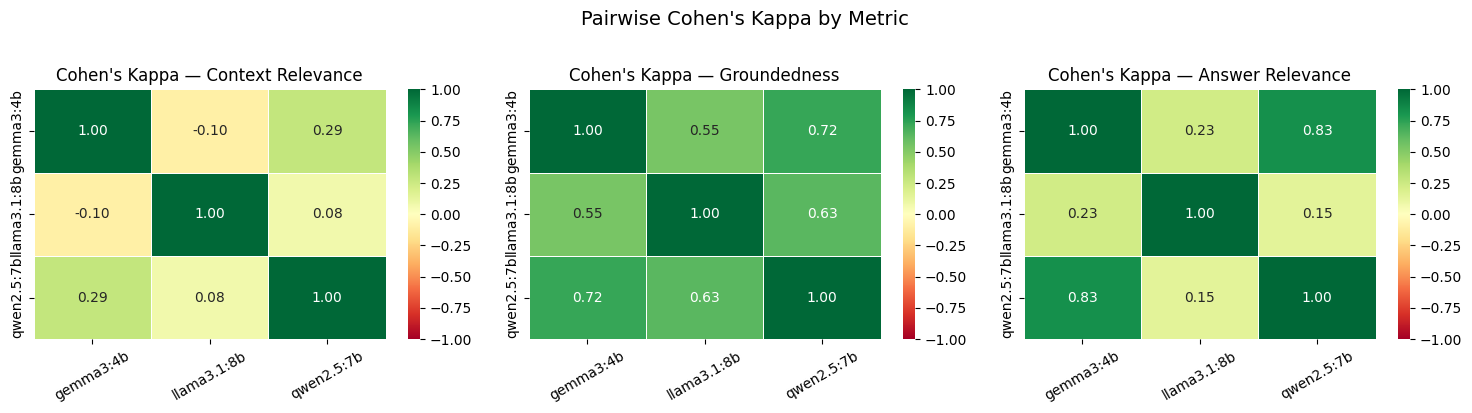

In [4]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, METRICS):
    if metric not in kappa_matrices or kappa_matrices[metric].empty:
        ax.set_visible(False)
        continue
    sns.heatmap(kappa_matrices[metric], annot=True, fmt=".2f", vmin=-1, vmax=1,
                center=0, cmap="RdYlGn", ax=ax, linewidths=0.5)
    ax.set_title(f"Cohen's Kappa — {metric.replace('_', ' ').title()}")
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("Pairwise Cohen's Kappa by Metric", fontsize=14, y=1.02)
fig.savefig(FIGURES_DIR / "03_kappa_heatmaps.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [5]:
# Fleiss' kappa (all 3 judges simultaneously) for each metric
print(f"{'Metric':30s}  {'Fleiss kappa':>12s}  {'Interpretation':20s}")
print("-" * 70)

fleiss_results = {}
if len(available) < 2:
    print("Need at least 2 annotators for Fleiss kappa — skipping.")
    fleiss_results = {m: float("nan") for m in METRICS}
else:
  for metric in METRICS:
    arrays = [scores[a][metric] for a in available]
    min_len = min(len(a) for a in arrays)
    matrix = np.column_stack([a[:min_len] for a in arrays])  # (n_items, n_annotators)
    k = fleiss_kappa(matrix)
    fleiss_results[metric] = k
    if k < 0.2:
        interp = "slight"
    elif k < 0.4:
        interp = "fair"
    elif k < 0.6:
        interp = "moderate"
    elif k < 0.8:
        interp = "substantial"
    else:
        interp = "near-perfect"
    print(f"{metric:30s}  {k:12.4f}  {interp:20s}")

fleiss_path = RESULTS_DIR / "03_fleiss_kappa.json"
fleiss_path.write_text(json.dumps(fleiss_results, indent=2))
print(f"Saved Fleiss kappa to {fleiss_path}")

Metric                          Fleiss kappa  Interpretation      
----------------------------------------------------------------------
context_relevance                     0.0943  slight              
groundedness                          0.6333  substantial         
answer_relevance                      0.3359  fair                
Saved Fleiss kappa to /workspaces/llm_judge_benchmark/outputs/results/03_fleiss_kappa.json



=== Spearman Correlation: context_relevance ===
             gemma3:4b  llama3.1:8b  qwen2.5:7b
gemma3:4b        1.000        0.302       0.814
llama3.1:8b      0.302        1.000       0.403
qwen2.5:7b       0.814        0.403       1.000

=== Spearman Correlation: groundedness ===
             gemma3:4b  llama3.1:8b  qwen2.5:7b
gemma3:4b        1.000        0.505       0.696
llama3.1:8b      0.505        1.000       0.369
qwen2.5:7b       0.696        0.369       1.000

=== Spearman Correlation: answer_relevance ===
             gemma3:4b  llama3.1:8b  qwen2.5:7b
gemma3:4b        1.000        0.345       0.683
llama3.1:8b      0.345        1.000       0.187
qwen2.5:7b       0.683        0.187       1.000


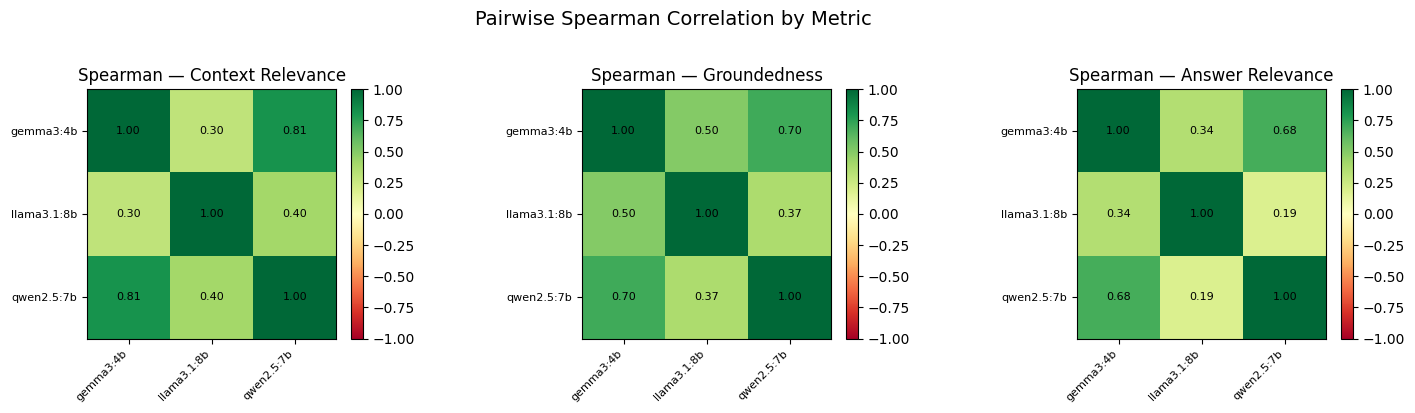

Saved Spearman matrices to /workspaces/llm_judge_benchmark/outputs/results/03_spearman_matrices.json


In [6]:
# Pairwise Spearman correlation matrices for each metric
spearman_matrices = {}
for metric in METRICS:
    rows = []
    for a1 in available:
        row = []
        for a2 in available:
            if a1 == a2:
                row.append(1.0)
            else:
                s1 = scores[a1][metric]
                s2 = scores[a2][metric]
                min_len = min(len(s1), len(s2))
                row.append(spearman(s1[:min_len], s2[:min_len])[0])
        rows.append(row)
    df_sp = pd.DataFrame(rows, index=available, columns=available)
    spearman_matrices[metric] = df_sp
    print(f"\n=== Spearman Correlation: {metric} ===")
    print(df_sp.round(3).to_string())

# Heatmap for Spearman
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
import matplotlib.cm as cm
for ax, metric in zip(axes, METRICS):
    mat = spearman_matrices[metric].values
    im = ax.imshow(mat, vmin=-1, vmax=1, cmap="RdYlGn")
    ax.set_xticks(range(len(available)))
    ax.set_yticks(range(len(available)))
    ax.set_xticklabels(available, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(available, fontsize=8)
    ax.set_title(f"Spearman — {metric.replace('_', ' ').title()}")
    for i in range(len(available)):
        for j in range(len(available)):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("Pairwise Spearman Correlation by Metric", fontsize=14, y=1.02)
fig.savefig(FIGURES_DIR / "03_spearman_heatmaps.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

spearman_export = {metric: df.to_dict() for metric, df in spearman_matrices.items()}
spearman_path = RESULTS_DIR / "03_spearman_matrices.json"
spearman_path.write_text(json.dumps(spearman_export, indent=2))
print(f"Saved Spearman matrices to {spearman_path}")

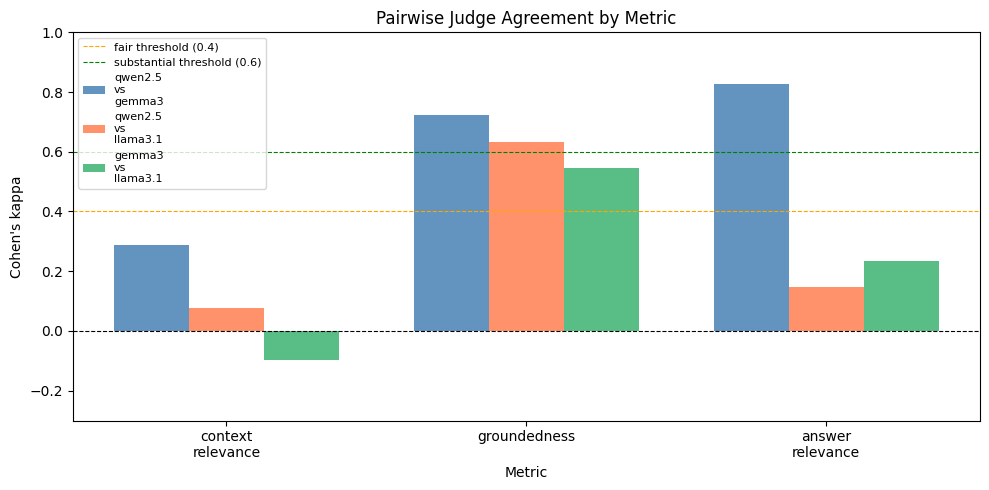

In [7]:
# Pairwise kappa bar chart: each model vs the other two
model_pairs = [
    ("qwen2.5:7b", "gemma3:4b"),
    ("qwen2.5:7b", "llama3.1:8b"),
    ("gemma3:4b", "llama3.1:8b"),
]

pair_labels = [f"{a.split(':')[0]}\nvs\n{b.split(':')[0]}" for a, b in model_pairs]

x = np.arange(len(METRICS))
width = 0.25
colors = ["steelblue", "coral", "mediumseagreen"]

fig, ax = plt.subplots(figsize=(10, 5))

for idx, (m_a, m_b) in enumerate(model_pairs):
    kappas = []
    for metric in METRICS:
        if m_a in scores and m_b in scores:
            s1 = scores[m_a][metric]
            s2 = scores[m_b][metric]
            min_len = min(len(s1), len(s2))
            kappas.append(cohen_kappa(s1[:min_len], s2[:min_len]))
        else:
            kappas.append(float("nan"))
    offset = (idx - 1) * width
    ax.bar(x + offset, kappas, width, label=pair_labels[idx], color=colors[idx], alpha=0.85)

ax.set_xlabel("Metric")
ax.set_ylabel("Cohen's kappa")
ax.set_title("Pairwise Judge Agreement by Metric")
ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", "\n") for m in METRICS])
ax.axhline(0.0, color="black", linewidth=0.8, linestyle="--")
ax.axhline(0.4, color="orange", linewidth=0.8, linestyle="--", label="fair threshold (0.4)")
ax.axhline(0.6, color="green", linewidth=0.8, linestyle="--", label="substantial threshold (0.6)")
ax.legend(fontsize=8)
ax.set_ylim(-0.3, 1.0)

fig.savefig(FIGURES_DIR / "03_kappa_by_metric.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()


In [8]:
# Key findings summary
if "qwen2.5:7b" in scores and "llama3.1:8b" in scores:
    s1 = scores["qwen2.5:7b"]["context_relevance"]
    s2 = scores["llama3.1:8b"]["context_relevance"]
    min_len = min(len(s1), len(s2))
    k_pair = cohen_kappa(s1[:min_len], s2[:min_len])
else:
    k_pair = float("nan")

best_fleiss_metric = max(fleiss_results, key=fleiss_results.get)
worst_fleiss_metric = min(fleiss_results, key=fleiss_results.get)

print("=" * 60)
print("KEY FINDINGS — Inter-Judge Agreement")
print("=" * 60)
print(f"  qwen2.5:7b vs llama3.1:8b kappa (context_relevance): {k_pair:.3f}")
print(f"  (No external reference — Fleiss kappa measures 3-way inter-judge agreement)")
print()
print("  Fleiss kappa by metric:")
for metric, k in fleiss_results.items():
    print(f"    {metric:30s}: {k:.4f}")
print()
print(f"  Best  Fleiss agreement: {best_fleiss_metric}  ({fleiss_results[best_fleiss_metric]:.4f})")
print(f"  Worst Fleiss agreement: {worst_fleiss_metric}  ({fleiss_results[worst_fleiss_metric]:.4f})")
print()
if available:
    all_kappas = []
    for metric in METRICS:
        for i, a1 in enumerate(available):
            for a2 in available[i+1:]:
                s1 = scores[a1][metric]
                s2 = scores[a2][metric]
                min_len = min(len(s1), len(s2))
                all_kappas.append(cohen_kappa(s1[:min_len], s2[:min_len]))
    mean_kappa = np.mean(all_kappas)
    print(f"  Mean pairwise kappa across all pairs/metrics: {mean_kappa:.4f}")
    below_06 = sum(1 for k in all_kappas if k < 0.6) / len(all_kappas) * 100
    print(f"  Fraction of pairs with kappa < 0.6 (not substantial): {below_06:.1f}%")
print("=" * 60)

KEY FINDINGS — Inter-Judge Agreement
  qwen2.5:7b vs llama3.1:8b kappa (context_relevance): 0.077
  (No external reference — Fleiss kappa measures 3-way inter-judge agreement)

  Fleiss kappa by metric:
    context_relevance             : 0.0943
    groundedness                  : 0.6333
    answer_relevance              : 0.3359

  Best  Fleiss agreement: groundedness  (0.6333)
  Worst Fleiss agreement: context_relevance  (0.0943)

  Mean pairwise kappa across all pairs/metrics: 0.3750
  Fraction of pairs with kappa < 0.6 (not substantial): 66.7%


Proceed to notebook **04** for per-judge divergence from ensemble consensus.
